# Code for doing the different clustering methods, as well as data preprocessing

In [104]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris # example dataset
from sklearn.metrics import silhouette_score, davies_bouldin_score


### Z-normalization

In [55]:
def perform_z_normalization(features_df: pd.DataFrame, group: int = "all"):
    z_normalized_df = features_df.apply(zscore)
    if group != "all":
        z_normalized_df = features_df[features_df['group'] == group]
    return z_normalized_df

### Principal Component Analysis (PCA)

In [56]:
def perform_PCA(features_df: pd.DataFrame = None, n_components=10, group="all"):
    '''
    Docstring for do_PCA
    Performs PCA on the provided dataset or the Iris dataset by default.
    Parameters:
        data: Optional, a dataset object with 'data' and 'target' attributes.
    Returns:
        pca_df: A DataFrame containing the first two principal components and the target labels.
    '''

    if group != "all":
        features_df = features_df[features_df['group'] == group]

    # Load and normalize the data
    if features_df is None:
        iris = load_iris(as_frame=True)
        n_components = 3  # Iris dataset has only 4 features
        X = iris.data
        y = iris.target
    else:
        X = features_df
    
    X_scaled = StandardScaler().fit_transform(X)

    # Intialize PCA
    pca = PCA(n_components=n_components)

    # Fit and transform the data
    X_pca = pca.fit_transform(X_scaled)

    print(f"Orignial shappe: {X.shape}")
    print(f"Transformed shape: {X_pca.shape}")
    print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
    print(f"Cumulative explained variance: {pca.explained_variance_ratio_.cumsum()}")

    pca_df = pd.DataFrame(data=X_pca,
                         columns=[f'PC{i+1}' for i in range(n_components)])
    pca_df['Target'] = y
    print(pca_df.head())

    return pca_df, n_components


Orignial shappe: (150, 4)
Transformed shape: (150, 3)
Explained variance ratio: [0.72962445 0.22850762 0.03668922]
Cumulative explained variance: [0.72962445 0.95813207 0.99482129]
        PC1       PC2       PC3  Target
0 -2.264703  0.480027  0.127706       0
1 -2.080961 -0.674134  0.234609       0
2 -2.364229 -0.341908 -0.044201       0
3 -2.299384 -0.597395 -0.091290       0
4 -2.389842  0.646835 -0.015738       0


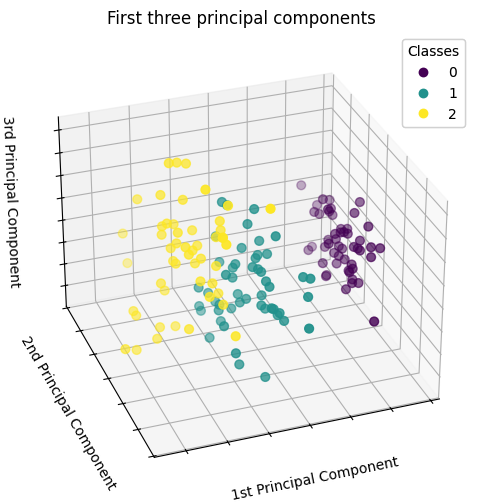

In [60]:
pca_df, n_components_pca = perform_PCA()

import matplotlib.pyplot as plt

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

scatter = ax.scatter(
    pca_df.iloc[:, 0],
    pca_df.iloc[:, 1],
    pca_df.iloc[:, 2],
    c=pca_df['Target'],
    s=40,
)

ax.set(
    title="First three principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    pca_df['Target'].unique(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

### K-means clustering

In [102]:
from sklearn.cluster import KMeans
import seaborn as sns

def perform_kmeans_clustering_initial(scores: pd.DataFrame):
    '''
    Docstring for perform_kmeans_clustering
    Performs k-means clustering on the PCA-transformed data.
    Parameters:
        scores: A DataFrame containing PCA components.
    
    '''
    # Within Cluster Sum of Squares (WCSS) using Ward's method
    WCSS = []
    for i in range(1, 30):
        clustering = KMeans(n_clusters=i, init='k-means++')
        clustering.fit(scores)  
        WCSS.append(clustering.inertia_)

    # Plotting the WCSS to visualize the elbow method
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, 30), WCSS, marker='o')
    plt.grid()
    plt.title('Elbow Method for Optimal Number of Clusters')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.show()



def perform_kmeans_clustering_final(scores: pd.DataFrame, n_clusters: int, plotting: bool = False):
    '''
    Docstring for perform_kmeans_clustering_final
    Performs k-means clustering on the PCA-transformed data with a specified number of clusters. Returns the scores with cluster labels.
    Parameters:
        scores: A DataFrame containing PCA components.
        n_clusters: The number of clusters to form.
    
    '''
    clustering = KMeans(n_clusters=n_clusters, init='k-means++')
    cluster_labels = clustering.fit_predict(scores)

    # Add cluster labels to the scores DataFrame
    scores['Cluster'] = cluster_labels

    if plotting:
        # Visualize the clustering results using pairplot
        sns.pairplot(scores, hue='Cluster')
        plt.suptitle('K-Means Clustering Results', y=1.02)
        plt.show()

    return scores, cluster_labels

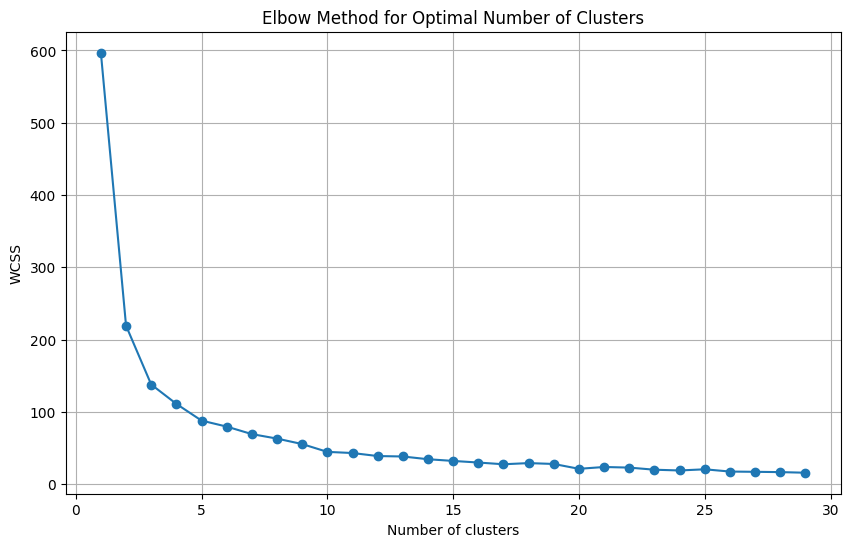

Silhouette Score for 3 clusters: 0.46928366701283664
Davies-Bouldin Score for 3 clusters: 0.8163834521489329


In [105]:
perform_kmeans_clustering_initial(pca_df.iloc[:, :n_components_pca])
pca_df_clusters, clustering = perform_kmeans_clustering_final(pca_df.iloc[:, :n_components_pca]  , n_clusters=3)

# Evaluate clustering performance using silhouette score and Davies-Bouldin score
silhouette_avg = silhouette_score(pca_df.iloc[:, :n_components_pca], clustering)
print(f'Silhouette Score for {3} clusters: {silhouette_avg}')
davies_bouldin_avg = davies_bouldin_score(pca_df.iloc[:, :n_components_pca], clustering)
print(f'Davies-Bouldin Score for {3} clusters: {davies_bouldin_avg}')

### Autoencoder 

Try to use a Convolutional Autoencoder's encoding layer to cluster the data

In [107]:
from torch import Tensor
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from Autoencoder import Encoder, Decoder, AutoEncoder

Load the data, apply the model and perform kmeans clustering

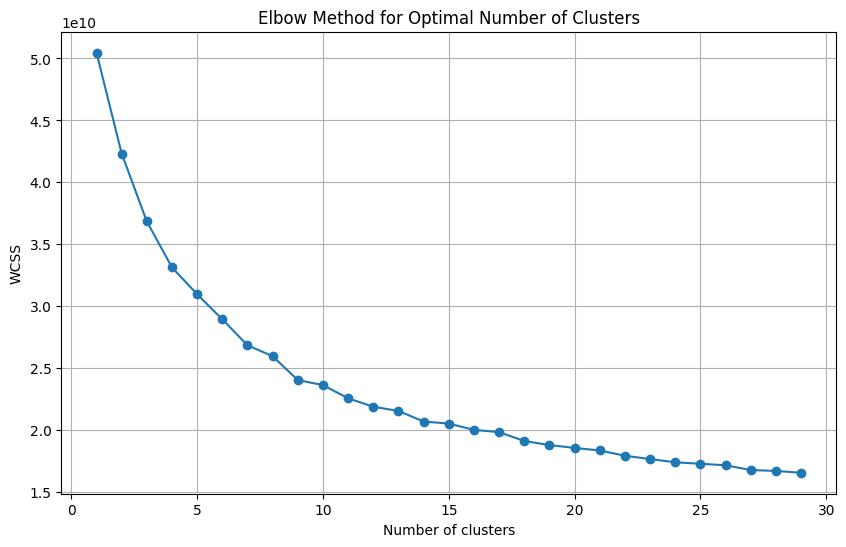

Silhouette Score for 10 clusters: 0.1970006376504898
Davies-Bouldin Score for 10 clusters: 1.6452222089906403


In [108]:

model = torch.load("./autoencoder_model_finetuned", weights_only=False)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load MNIST_data
data = np.load("MNIST_data.npz")
X = data['X']
y = data['y']

# Apply the model and get the embedded representation
X_embedded_pretrained = model(Tensor(X).to(device))[0]

# Detach from gpu
X_embedded_cpu = X_embedded_pretrained.detach().cpu()

# Make dataframe
X_embedded_df = pd.DataFrame(X_embedded_cpu.numpy())

# Apply kmeans clustering
perform_kmeans_clustering_initial(X_embedded_df)
X_embedded_df, clustering = perform_kmeans_clustering_final(X_embedded_df, n_clusters=10)

# Evaluate clustering performance using silhouette score
silhouette_avg = silhouette_score(X_embedded_df.iloc[:, :-1], clustering)
print(f'Silhouette Score for {10} clusters: {silhouette_avg}')
davies_bouldin_avg = davies_bouldin_score(X_embedded_df.iloc[:, :-1], clustering)
print(f'Davies-Bouldin Score for {10} clusters: {davies_bouldin_avg}')


### UMAP